# 6. Modelling

## 6.1 Modelos sin Feature engineering

**1. Preparación de datos**

In [51]:

# Features y target
FEATURES = VARS_IPM + ['año', 'latitud', 'longitud']
TARGET   = 'riesgo'


In [52]:
# SPLIT TEMPORAL
# Verificar que no hay fuga de datos
assert 'casos_totales' not in FEATURES, "FUGA DE DATOS: casos_totales no puede ser feature"
assert 'tasa_x1000'    not in FEATURES, "FUGA DE DATOS: tasa_x1000 no puede ser feature"

# Subset final
df_mod = df_final[FEATURES + [TARGET, 'cod_mun']].dropna().copy()
# Convert 'año' column to integer type
df_mod['año'] = df_mod['año'].astype(int)

# Encode target: bajo=0, medio=1, alto=2
le = LabelEncoder()
le.classes_ = np.array(ORDEN)
df_mod['riesgo_enc'] = le.transform(df_mod[TARGET])

# Guardar para interpretar predicciones
joblib.dump(le, 'label_encoder.pkl')

# ── Split temporal: train 2018-2022 / test 2023-2024 ──
# Justificación: simula el caso de uso real (predecir con datos históricos)
TRAIN_AÑOS = [2018, 2019, 2020, 2021, 2022]
TEST_AÑOS  = [2023, 2024]

train = df_mod[df_mod['año'].isin(TRAIN_AÑOS)].copy()
test  = df_mod[df_mod['año'].isin(TEST_AÑOS)].copy()

X_train = train[FEATURES]
y_train = train['riesgo_enc']
X_test  = test[FEATURES]
y_test  = test['riesgo_enc']
grupos  = train['cod_mun']   # para cross-validation agrupada

print("=" * 56)
print("  DISEÑO DE VALIDACIÓN")
print("=" * 56)
print(f"\n  Split temporal:")
print(f"    Train  {TRAIN_AÑOS[0]}–{TRAIN_AÑOS[-1]}:  {len(train):,} filas")
print(f"    Test   {TEST_AÑOS[0]}–{TEST_AÑOS[-1]}:  {len(test):,} filas")
print(f"\n  Distribución train:")
for cat, enc in zip(ORDEN, [0,1,2]):
    n   = (y_train == enc).sum()
    pct = n / len(y_train) * 100
    print(f"    {cat.upper():<8} {n:>5,}  ({pct:.1f}%)")
print(f"\n  Distribución test:")
for cat, enc in zip(ORDEN, [0,1,2]):
    n   = (y_test == enc).sum()
    pct = n / len(y_test) * 100
    print(f"    {cat.upper():<8} {n:>5,}  ({pct:.1f}%)")

print(f"\n  Estrategia CV: StratifiedGroupKFold (5 folds)")
print(f"  Grupos: municipio — evita fuga de información espacial")
print(f"  Métrica principal: F1-macro (clases balanceadas)")

  DISEÑO DE VALIDACIÓN

  Split temporal:
    Train  2018–2022:  4,388 filas
    Test   2023–2024:  1,942 filas

  Distribución train:
    BAJO     1,476  (33.6%)
    MEDIO    1,469  (33.5%)
    ALTO     1,443  (32.9%)

  Distribución test:
    BAJO       656  (33.8%)
    MEDIO      647  (33.3%)
    ALTO       639  (32.9%)

  Estrategia CV: StratifiedGroupKFold (5 folds)
  Grupos: municipio — evita fuga de información espacial
  Métrica principal: F1-macro (clases balanceadas)


**2. Modelo base de comparación**

In [53]:
print("=" * 56)
print("  MODELO 1 — BASELINE: REGRESIÓN LOGÍSTICA ELASTIC NET")
print("=" * 56)

# Elastic Net combina L1 (selección de variables) y L2 (regularización)
# Es el baseline interpretable obligatorio
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),          # necesario para regresión logística
    ('model',  LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,                      # 50% L1 + 50% L2
        C=0.1,                             # regularización fuerte
        max_iter=2000,
        random_state=42
    ))
])

# CV agrupada por municipio (5 folds)
cv = StratifiedGroupKFold(n_splits=5)
cv_scores_lr = cross_val_score(
    pipe_lr, X_train, y_train,
    cv=cv, groups=grupos,
    scoring='f1_macro', n_jobs=-1
)

# Entrenar en todo el train
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

# Métricas
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
auc_lr = roc_auc_score(y_test, pipe_lr.predict_proba(X_test),
                        multi_class='ovr', average='macro')

print(f"\n  CV F1-macro (train): {cv_scores_lr.mean():.3f} \u00b1 {cv_scores_lr.std():.3f}")
print(f"  F1-macro (test):     {f1_lr:.3f}")
print(f"  AUC-ROC (test):      {auc_lr:.3f}")
print(f"\n  Reporte de clasificación (test):")
print(classification_report(y_test, y_pred_lr,
                             target_names=ORDEN, digits=3))

  MODELO 1 — BASELINE: REGRESIÓN LOGÍSTICA ELASTIC NET

  CV F1-macro (train): 0.478 ± 0.015
  F1-macro (test):     0.429
  AUC-ROC (test):      0.609

  Reporte de clasificación (test):
              precision    recall  f1-score   support

        bajo      0.442     0.538     0.486       656
       medio      0.384     0.274     0.319       647
        alto      0.466     0.498     0.481       639

    accuracy                          0.437      1942
   macro avg      0.431     0.436     0.429      1942
weighted avg      0.431     0.437     0.429      1942



**3. Modelo Random Forest**

In [54]:
print("=" * 56)
print("  MODELO 2 — RANDOM FOREST")
print("=" * 56)

# Random Forest: captura no linealidad, robusto a outliers
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,              # controla sobreajuste
    min_samples_leaf=20,      # mínimo de observaciones por hoja
    min_samples_split=40,
    max_features='sqrt',      # raíz de features en cada split
    class_weight='balanced',  # robustez ante posible desbalance residual
    random_state=42,
    n_jobs=-1
)

cv_scores_rf = cross_val_score(
    rf, X_train, y_train,
    cv=cv, groups=grupos,
    scoring='f1_macro', n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test),
                        multi_class='ovr', average='macro')

print(f"\n  CV F1-macro (train): {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")
print(f"  F1-macro (test):     {f1_rf:.3f}")
print(f"  AUC-ROC (test):      {auc_rf:.3f}")
print(f"\n  Reporte de clasificación (test):")
print(classification_report(y_test, y_pred_rf,
                             target_names=ORDEN, digits=3))



  MODELO 2 — RANDOM FOREST

  CV F1-macro (train): 0.494 ± 0.013
  F1-macro (test):     0.463
  AUC-ROC (test):      0.655

  Reporte de clasificación (test):
              precision    recall  f1-score   support

        bajo      0.492     0.579     0.532       656
       medio      0.377     0.317     0.344       647
        alto      0.519     0.509     0.514       639

    accuracy                          0.469      1942
   macro avg      0.463     0.468     0.463      1942
weighted avg      0.463     0.469     0.464      1942



**4. Modelo XGBoost**

In [55]:
print("=" * 56)
print("  MODELO 3 — XGBOOST")
print("=" * 56)

# XGBoost: gradient boosting, mejor con datos tabulares estructurados
# Más sensible a hiperparámetros que RF pero suele ganar en métricas
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,              # árboles poco profundos + muchos = mejor generalización
    learning_rate=0.05,       # bajo para converger despacio y no sobreajustar
    subsample=0.8,            # 80% de filas por árbol (reduce varianza)
    colsample_bytree=0.8,     # 80% de features por árbol
    reg_alpha=0.1,            # L1
    reg_lambda=1.0,           # L2
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

cv_scores_xgb = cross_val_score(
    xgb, X_train, y_train,
    cv=cv, groups=grupos,
    scoring='f1_macro', n_jobs=-1
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)
y_pred_xgb = xgb.predict(X_test)

f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')
auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test),
                          multi_class='ovr', average='macro')

print(f"\n  CV F1-macro (train): {cv_scores_xgb.mean():.3f} ± {cv_scores_xgb.std():.3f}")
print(f"  F1-macro (test):     {f1_xgb:.3f}")
print(f"  AUC-ROC (test):      {auc_xgb:.3f}")
print(f"\n  Reporte de clasificación (test):")
print(classification_report(y_test, y_pred_xgb,
                             target_names=ORDEN, digits=3))


  MODELO 3 — XGBOOST

  CV F1-macro (train): 0.490 ± 0.005
  F1-macro (test):     0.484
  AUC-ROC (test):      0.675

  Reporte de clasificación (test):
              precision    recall  f1-score   support

        bajo      0.511     0.558     0.534       656
       medio      0.379     0.352     0.365       647
        alto      0.558     0.546     0.552       639

    accuracy                          0.486      1942
   macro avg      0.483     0.485     0.484      1942
weighted avg      0.483     0.486     0.484      1942



**5. Comparación modelos**


  TABLA COMPARATIVA DE MODELOS
               Modelo  CV F1-macro  CV Std  Test F1-macro  Test AUC-ROC
Logística Elastic Net        0.478   0.015          0.429         0.609
        Random Forest        0.494   0.013          0.463         0.655
              XGBoost        0.490   0.005          0.484         0.675


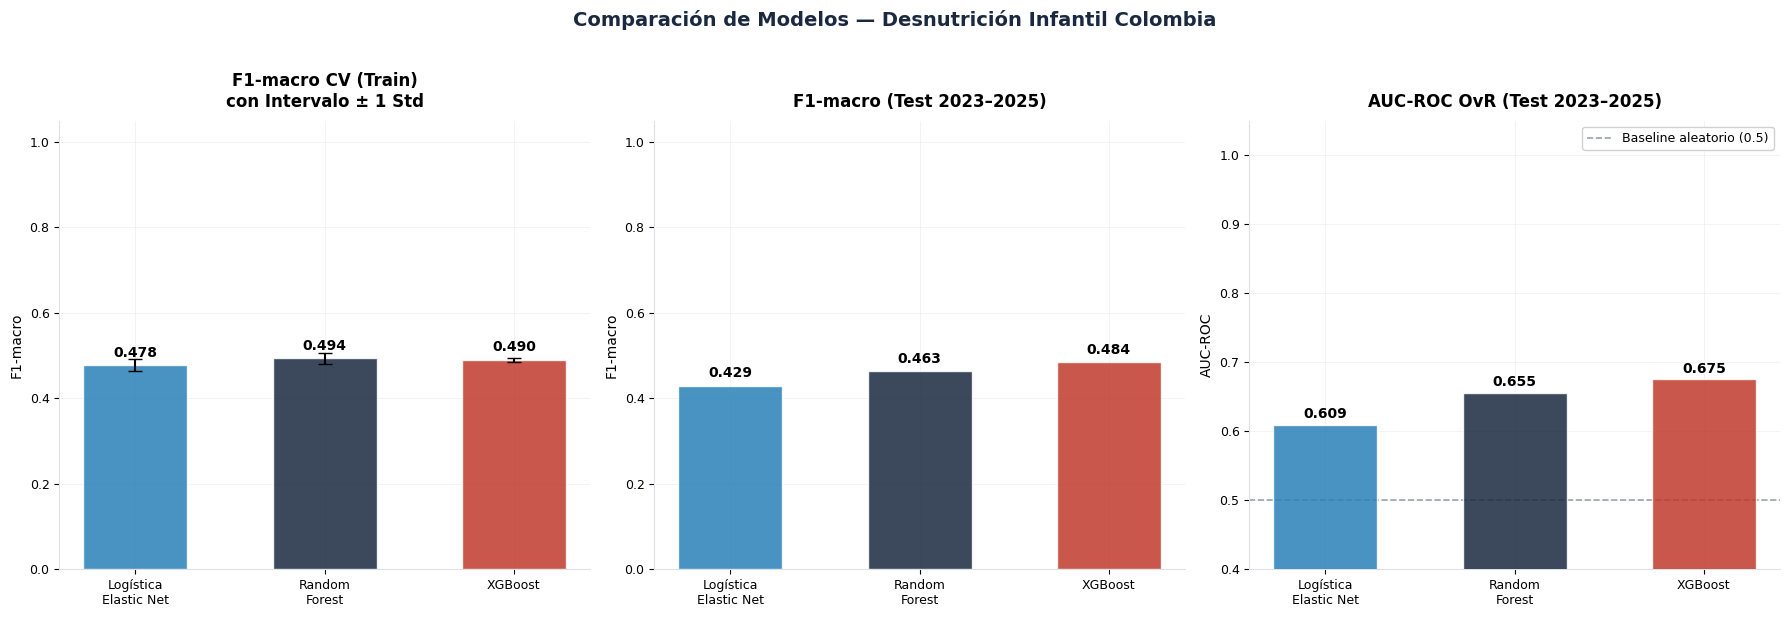

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Modelos — Desnutrición Infantil Colombia',
             fontsize=14, fontweight='bold', color=C['primary'], y=1.02)

# ── Tabla resumen ──
resultados = pd.DataFrame({
    'Modelo': ['Logística Elastic Net', 'Random Forest', 'XGBoost'],
    'CV F1-macro': [cv_scores_lr.mean(), cv_scores_rf.mean(), cv_scores_xgb.mean()],
    'CV Std':      [cv_scores_lr.std(),  cv_scores_rf.std(),  cv_scores_xgb.std()],
    'Test F1-macro': [f1_lr,  f1_rf,  f1_xgb],
    'Test AUC-ROC':  [auc_lr, auc_rf, auc_xgb],
}).round(3)

print("\n" + "=" * 56)
print("  TABLA COMPARATIVA DE MODELOS")
print("=" * 56)
print(resultados.to_string(index=False))

# 5.1 F1-macro CV con barras de error
modelos     = resultados['Modelo'].tolist()
cv_means    = resultados['CV F1-macro'].tolist()
cv_stds     = resultados['CV Std'].tolist()
test_f1s    = resultados['Test F1-macro'].tolist()
colores_mod = [C['accent'], C['primary'], C['alto']]

x = np.arange(len(modelos))
bars = axes[0].bar(x, cv_means, color=colores_mod, alpha=0.85,
                   edgecolor='white', width=0.55, zorder=3)
axes[0].errorbar(x, cv_means, yerr=cv_stds, fmt='none',
                 color='black', capsize=5, linewidth=1.5, zorder=4)
axes[0].set_title('F1-macro CV (Train)\ncon Intervalo ± 1 Std')
axes[0].set_ylabel('F1-macro'); axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Logística\nElastic Net','Random\nForest','XGBoost'], fontsize=9)
for bar, val in zip(bars, cv_means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# 5.2 F1-macro Test
bars2 = axes[1].bar(x, test_f1s, color=colores_mod, alpha=0.85,
                    edgecolor='white', width=0.55, zorder=3)
axes[1].set_title('F1-macro (Test 2023–2025)')
axes[1].set_ylabel('F1-macro'); axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Logística\nElastic Net','Random\nForest','XGBoost'], fontsize=9)
for bar, val in zip(bars2, test_f1s):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# 5.3 AUC-ROC Test
bars3 = axes[2].bar(x, resultados['Test AUC-ROC'].tolist(),
                    color=colores_mod, alpha=0.85, edgecolor='white', width=0.55, zorder=3)
axes[2].axhline(0.5, color=C['mid'], ls='--', lw=1.2, label='Baseline aleatorio (0.5)')
axes[2].set_title('AUC-ROC OvR (Test 2023–2025)')
axes[2].set_ylabel('AUC-ROC'); axes[2].set_ylim(0.4, 1.05)
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Logística\nElastic Net','Random\nForest','XGBoost'], fontsize=9)
axes[2].legend()
for bar, val in zip(bars3, resultados['Test AUC-ROC'].tolist()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mod_01_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


**6. Matrices de confusión**

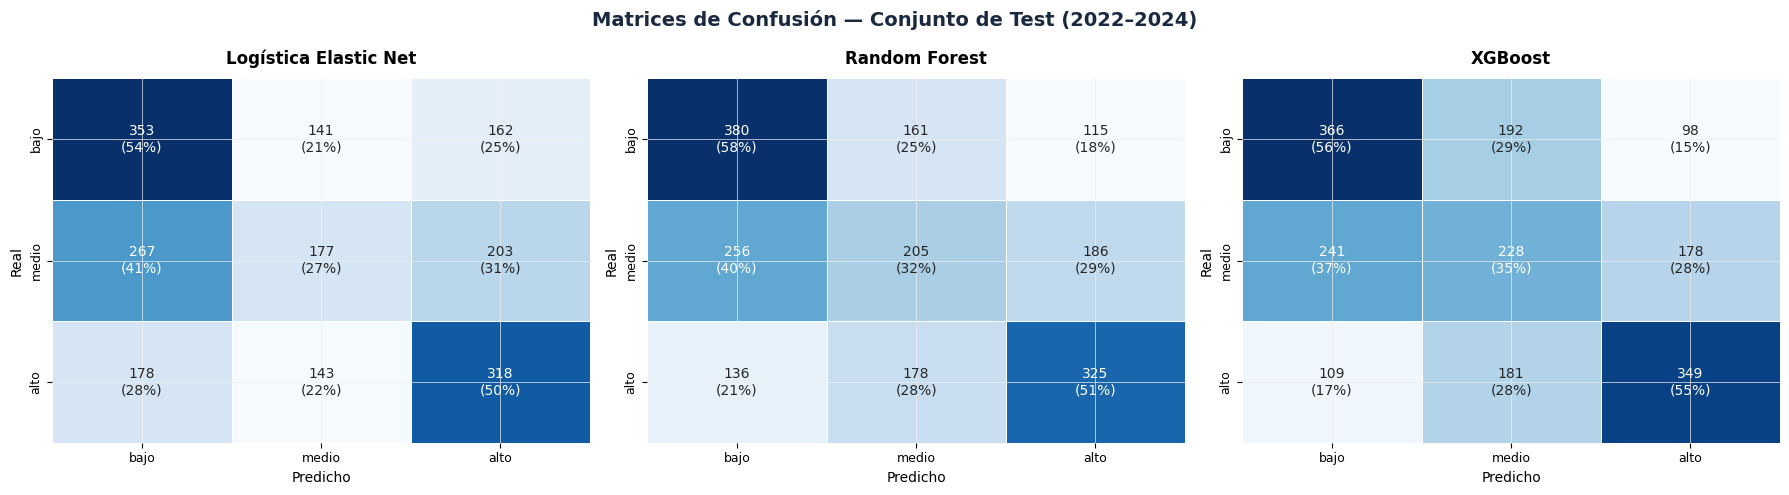

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Conjunto de Test (2022–2024)',
             fontsize=14, fontweight='bold', color=C['primary'])

predicciones = [
    ('Logística Elastic Net', y_pred_lr,  C['accent']),
    ('Random Forest',          y_pred_rf,  C['primary']),
    ('XGBoost',                y_pred_xgb, C['alto']),
]

for ax, (nombre, y_pred, color) in zip(axes, predicciones):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Mostrar valores absolutos + porcentaje
    annot = np.array([[f'{v}\n({p:.0f}%)'
                        for v, p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=annot, fmt='', ax=ax,
                cmap='Blues', linewidths=0.5, linecolor='white',
                xticklabels=ORDEN, yticklabels=ORDEN,
                cbar=False, annot_kws={'size': 10})
    ax.set_title(nombre)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('mod_02_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2 Modelos con Feature engineering Territorial y Climático

**1. Preparación de los datos**

In [58]:
FEATURES_TOPO_CLIMA = FEATURES + [
    'inter_primera_infancia_rural',
    'inter_tasa_dependencia_rural',
    'inter_sin_agua_mejorada_rural',
    'area_km2',
    'altitud_m',
    'log_altitud',
    'piso_termico',
]

# Codificar target — mismo criterio usado en los modelos anteriores

df_final['riesgo_enc'] = le.transform(df_final[TARGET])

df_final['año'] = df_final['año'].astype(int)

**2. Función de entrenamiento/evaluación**

In [59]:
def entrenar_evaluar_xgb(df, features, target, nombre_modelo,
                          años_train= TRAIN_AÑOS,
                          años_test= TEST_AÑOS,
                          group_col='cod_mun'):

    train = df[df['año'].isin(años_train)]
    test  = df[df['año'].isin(años_test)]

    X_tr, y_tr = train[features], train[target]
    X_te, y_te = test[features],  test[target]
    grupos     = train[group_col]

    print(f"[{nombre_modelo}] Train: {len(train):,}  Test: {len(test):,}  "
          f"Ratio obs/features: {len(train)/len(features):.1f}:1")

    modelo = XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.75,
        colsample_bytree=0.6,
        min_child_weight=15,
        reg_alpha=1.0,
        reg_lambda=3.0,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )

    cv = StratifiedGroupKFold(n_splits=5)
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv, groups=grupos,
                                 scoring='f1_macro', n_jobs=-1)

    modelo.fit(X_tr, y_tr, verbose=False)
    y_pred = modelo.predict(X_te)
    f1  = f1_score(y_te, y_pred, average='macro')
    auc = roc_auc_score(y_te, modelo.predict_proba(X_te),
                         multi_class='ovr', average='macro')

    print(f"[{nombre_modelo}] CV f1_macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"[{nombre_modelo}] Test  F1: {f1:.3f}   AUC: {auc:.3f}\n")

    return modelo, f1, auc, y_pred, y_te



**3. Entrenar los dos modelos por separado**

In [60]:
xgb, f1_base, auc_base, y_pred_base, y_te_base = entrenar_evaluar_xgb(
    df_final, FEATURES, 'riesgo_enc', nombre_modelo='base'
)

xgb_topo_clima, f1_tc, auc_tc, y_pred_tc, y_te_tc = entrenar_evaluar_xgb(
    df_final, FEATURES_TOPO_CLIMA, 'riesgo_enc', nombre_modelo='topo_clima'
)


[base] Train: 4,388  Test: 1,942  Ratio obs/features: 243.8:1
[base] CV f1_macro: 0.494 ± 0.010
[base] Test  F1: 0.486   AUC: 0.668

[topo_clima] Train: 4,388  Test: 1,942  Ratio obs/features: 175.5:1
[topo_clima] CV f1_macro: 0.490 ± 0.010
[topo_clima] Test  F1: 0.481   AUC: 0.669



**4. Comparación**

In [61]:
print(f"\n{'='*58}")
print(f"  BASE  vs  BASE + TOPOGRAFÍA/CLIMA")
print(f"{'='*58}")
for nombre, f1, auc in [
    ('base (FEATURES)',                       f1_base, auc_base),
    ('+ topografía y clima (FEATURES_TOPO_CLIMA)', f1_tc, auc_tc),
]:
    delta_f1  = f1  - f1_base
    delta_auc = auc - auc_base
    print(f"  {nombre:<45}  F1={f1:.3f} ({delta_f1:+.3f})  AUC={auc:.3f} ({delta_auc:+.3f})")

print(f"\n  Reporte — modelo con topografía y clima:")
print(classification_report(y_te_tc, y_pred_tc, target_names=ORDEN, digits=3))


  BASE  vs  BASE + TOPOGRAFÍA/CLIMA
  base (FEATURES)                                F1=0.486 (+0.000)  AUC=0.668 (+0.000)
  + topografía y clima (FEATURES_TOPO_CLIMA)     F1=0.481 (-0.005)  AUC=0.669 (+0.000)

  Reporte — modelo con topografía y clima:
              precision    recall  f1-score   support

        bajo      0.499     0.564     0.530       656
       medio      0.388     0.351     0.369       647
        alto      0.554     0.534     0.543       639

    accuracy                          0.483      1942
   macro avg      0.480     0.483     0.481      1942
weighted avg      0.480     0.483     0.481      1942



## 6.3 Modelo con feature engineering de lag

**1. Preparación de los datos**

In [62]:
FEATURES_AVANZADO = FEATURES_TOPO_CLIMA + FEATURES_LAG + [
    'dist_capital_dpto',
    'dist_bogota',
    'dist_ciudad_cercana',
]

# por si alguna columna se repite entre listas (ej. si FEATURES_MEFM
# ya trae algo de FEATURES_TOPO_CLIMA por error), quita duplicados
# preservando el orden:
FEATURES_AVANZADO = list(dict.fromkeys(FEATURES_AVANZADO))

print(f"FEATURES               : {len(FEATURES)} variables")
print(f"FEATURES_TOPO_CLIMA    : {len(FEATURES_TOPO_CLIMA)} variables")
print(f"FEATURES_AVANZADO      : {len(FEATURES_AVANZADO)} variables "
      f"(+{len(FEATURES_AVANZADO) - len(FEATURES_TOPO_CLIMA)} sobre topo_clima)")

FEATURES               : 18 variables
FEATURES_TOPO_CLIMA    : 25 variables
FEATURES_AVANZADO      : 33 variables (+8 sobre topo_clima)


**2. Entrenamiento del modelo con features avanzados**

In [63]:
xgb_avanzado, f1_av, auc_av, y_pred_av, y_te_av = entrenar_evaluar_xgb(
    df_final, FEATURES_AVANZADO, 'riesgo_enc', nombre_modelo='avanzado'
)

[avanzado] Train: 4,388  Test: 1,942  Ratio obs/features: 133.0:1
[avanzado] CV f1_macro: 0.525 ± 0.013
[avanzado] Test  F1: 0.514   AUC: 0.709



**3.  Comparación de los tres modelos**

In [64]:
print(f"\n{'='*58}")
print(f"  BASE  vs  + TOPOGRAFÍA/CLIMA  vs  + AVANZADO")
print(f"{'='*58}")
for nombre, f1, auc in [
    ('base (FEATURES)',                       f1_base, auc_base),
    ('+ topografía y clima (FEATURES_TOPO_CLIMA)', f1_tc, auc_tc),
    ('+ avanzado — MEFM/dist/EBLUP (FEATURES_AVANZADO)', f1_av, auc_av),
]:
    delta_f1  = f1  - f1_base
    delta_auc = auc - auc_base
    print(f"  {nombre:<48}  F1={f1:.3f} ({delta_f1:+.3f})  AUC={auc:.3f} ({delta_auc:+.3f})")

print(f"\n  Reporte — modelo avanzado:")
print(classification_report(y_te_av, y_pred_av, target_names=ORDEN, digits=3))



  BASE  vs  + TOPOGRAFÍA/CLIMA  vs  + AVANZADO
  base (FEATURES)                                   F1=0.486 (+0.000)  AUC=0.668 (+0.000)
  + topografía y clima (FEATURES_TOPO_CLIMA)        F1=0.481 (-0.005)  AUC=0.669 (+0.000)
  + avanzado — MEFM/dist/EBLUP (FEATURES_AVANZADO)  F1=0.514 (+0.028)  AUC=0.709 (+0.041)

  Reporte — modelo avanzado:
              precision    recall  f1-score   support

        bajo      0.584     0.502     0.540       656
       medio      0.409     0.416     0.413       647
        alto      0.557     0.629     0.591       639

    accuracy                          0.515      1942
   macro avg      0.517     0.515     0.514      1942
weighted avg      0.517     0.515     0.514      1942

